## Import Librabries 

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

In [6]:
# can we have multiple index in series and dataframe? Let's try
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
a = pd.Series([1,2,3,4,5,6,7,8,], index = index_val)
a

(cse, 2019)    1
(cse, 2020)    2
(cse, 2021)    3
(cse, 2022)    4
(ece, 2019)    5
(ece, 2020)    6
(ece, 2021)    7
(ece, 2022)    8
dtype: int64

In [8]:
# The problem in this approach of indexing
# a['cse']

In [ ]:
# The soltuion -> multiindex series(also known as hierarchical indexing)
# multiple index levels within a single index
# how to create a multiindex object
# 1. pd.MultiIndex.from_tuples()   # apply tuples
# 2. pd.MultiIndex.from_product()  # apply cartesian product

In [10]:
index_val = [('cse',2019),('cse',2020),('cse',2021),('cse',2022),('ece',2019),('ece',2020),('ece',2021),('ece',2022)]
multiindex = pd.MultiIndex.from_tuples(index_val)
multiindex

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [ ]:
# level inside multiindex object
multiindex.levels  # decouple the index

FrozenList([['cse', 'ece'], [2019, 2020, 2021, 2022]])

In [12]:
multiindex.levels[0]

Index(['cse', 'ece'], dtype='object')

In [13]:
multiindex.levels[1]

Index([2019, 2020, 2021, 2022], dtype='int64')

In [16]:
multiindex = pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]])
multiindex

MultiIndex([('cse', 2019),
            ('cse', 2020),
            ('cse', 2021),
            ('cse', 2022),
            ('ece', 2019),
            ('ece', 2020),
            ('ece', 2021),
            ('ece', 2022)],
           )

In [20]:
# creating a series with multiindex object
s = pd.Series([1,2,3,4,5,6,7,8], index = multiindex)
s

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [21]:
# how to fetch items from a such series
s[('cse',2022)]

np.int64(4)

In [22]:
s['cse']

2019    1
2020    2
2021    3
2022    4
dtype: int64

In [ ]:
# a logical question to ask
# Multindex series is a 2D object

In [ ]:
# unstack
temp = s.unstack()   #  convert mutiindex series into a dataframe
temp

,2019,2020,2021,2022
cse,1,2,3,4
ece,5,6,7,8


In [ ]:
# stack
temp.stack() # convert dataframe into mutiindex series

cse  2019    1
     2020    2
     2021    3
     2022    4
ece  2019    5
     2020    6
     2021    7
     2022    8
dtype: int64

In [ ]:
# Importance of Multiindex dataframe
# Multiindexing helps to display higher dimensions(3D, 4D e.t.c) data into a 2D Dataframe
# Multiindexing helps to represent the higher dimensions data into lower dimensions easily

In [32]:
# multiindex dataframe
branch_df1 = pd.DataFrame(
    [
        [1,2],
        [3,4],
        [5,6],
        [7,8],
        [9,10],
        [11,12],
        [13,14],
        [15,16]
    ],
    index = multiindex,
    columns = ['avg_package','students']
)

In [33]:
branch_df1

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [34]:
branch_df1.shape

(8, 2)

In [49]:
branch_df1.loc['cse']

,avg_package,students
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [48]:
branch_df1.loc[('cse',2019)]

avg_package    1
students       2
Name: (cse, 2019), dtype: int64

In [37]:
branch_df1['avg_package']

cse  2019     1
     2020     3
     2021     5
     2022     7
ece  2019     9
     2020    11
     2021    13
     2022    15
Name: avg_package, dtype: int64

In [ ]:
# Are columns really different from index?
# They are almost same

In [39]:
# multiindex dataframe from columns perspective
branch_df2 = pd.DataFrame(
 [
    [1,2,0,0],
    [3,4,0,0],
    [5,6,0,0],
    [7,8,0,0]
 ],
 index = [2019,2020,2021,2022],
 columns = pd.MultiIndex.from_product([['Kathmandu','Pokhara'],['avg_package','students']])
)

In [40]:
branch_df2

Kathmandu              Pokhara         
     avg_package students avg_package students
2019           1        2           0        0
2020           3        4           0        0
2021           5        6           0        0
2022           7        8           0        0

In [43]:
branch_df2['Kathmandu']

,avg_package,students
2019,1,2
2020,3,4
2021,5,6
2022,7,8


In [46]:
branch_df2['Kathmandu']['avg_package']

2019    1
2020    3
2021    5
2022    7
Name: avg_package, dtype: int64

In [45]:
branch_df2.loc[2019]

Kathmandu  avg_package    1
           students       2
Pokhara    avg_package    0
           students       0
Name: 2019, dtype: int64

In [50]:
# Multiindex dataframe in terms of both columns and rows
branch_df3 = pd.DataFrame(
    [
    [1,2,0,0],
    [3,4,0,0],
    [5,6,0,0],
    [7,8,0,0],
    [9,10,0,0],
    [11,12,0,0],
    [13,14,0,0],
    [15,16,0,0]
    ],
    index = pd.MultiIndex.from_product([['cse','ece'],[2019,2020,2021,2022]]),
    columns = pd.MultiIndex.from_product([['Kathmandu','Pokhara'],['avg_package','students']])
)

In [51]:
branch_df3

Kathmandu              Pokhara         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [81]:
branch_df3['Kathmandu']

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [82]:
branch_df3.loc[('cse',2019)]

Kathmandu  avg_package    1
           students       2
Pokhara    avg_package    0
           students       0
Name: (cse, 2019), dtype: int64

## Stacking and Unstacking
* Stacking converts columns into index
* Unstacking converts index into columns

In [83]:
branch_df1.unstack()  # inner index becomes columns

avg_package                students               
           2019 2020 2021 2022     2019 2020 2021 2022
cse           1    3    5    7        2    4    6    8
ece           9   11   13   15       10   12   14   16

In [84]:
branch_df1.unstack().unstack()  # series

avg_package  2019  cse     1
                   ece     9
             2020  cse     3
                   ece    11
             2021  cse     5
                   ece    13
             2022  cse     7
                   ece    15
students     2019  cse     2
                   ece    10
             2020  cse     4
                   ece    12
             2021  cse     6
                   ece    14
             2022  cse     8
                   ece    16
dtype: int64

In [85]:
branch_df1.unstack().unstack().loc[('avg_package',2019,'cse')]

np.int64(1)

In [86]:
branch_df1.unstack().stack().stack()

C:\Users\sanje\AppData\Local\Temp\ipykernel_14936\2994828746.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df1.unstack().stack().stack()


cse  2019  avg_package     1
           students        2
     2020  avg_package     3
           students        4
     2021  avg_package     5
           students        6
     2022  avg_package     7
           students        8
ece  2019  avg_package     9
           students       10
     2020  avg_package    11
           students       12
     2021  avg_package    13
           students       14
     2022  avg_package    15
           students       16
dtype: int64

In [87]:
branch_df2.unstack()


Kathmandu  avg_package  2019    1
                        2020    3
                        2021    5
                        2022    7
           students     2019    2
                        2020    4
                        2021    6
                        2022    8
Pokhara    avg_package  2019    0
                        2020    0
                        2021    0
                        2022    0
           students     2019    0
                        2020    0
                        2021    0
                        2022    0
dtype: int64

In [88]:
branch_df3.unstack().unstack()

Kathmandu  avg_package  2019  cse     1
                              ece     9
                        2020  cse     3
                              ece    11
                        2021  cse     5
                              ece    13
                        2022  cse     7
                              ece    15
           students     2019  cse     2
                              ece    10
                        2020  cse     4
                              ece    12
                        2021  cse     6
                              ece    14
                        2022  cse     8
                              ece    16
Pokhara    avg_package  2019  cse     0
                              ece     0
                        2020  cse     0
                              ece     0
                        2021  cse     0
                              ece     0
                        2022  cse     0
                              ece     0
           students     2019  cse     0


In [89]:
branch_df3.stack().stack()


C:\Users\sanje\AppData\Local\Temp\ipykernel_14936\4037618427.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  branch_df3.stack().stack()


cse  2019  avg_package  Kathmandu     1
                        Pokhara       0
           students     Kathmandu     2
                        Pokhara       0
     2020  avg_package  Kathmandu     3
                        Pokhara       0
           students     Kathmandu     4
                        Pokhara       0
     2021  avg_package  Kathmandu     5
                        Pokhara       0
           students     Kathmandu     6
                        Pokhara       0
     2022  avg_package  Kathmandu     7
                        Pokhara       0
           students     Kathmandu     8
                        Pokhara       0
ece  2019  avg_package  Kathmandu     9
                        Pokhara       0
           students     Kathmandu    10
                        Pokhara       0
     2020  avg_package  Kathmandu    11
                        Pokhara       0
           students     Kathmandu    12
                        Pokhara       0
     2021  avg_package  Kathmandu    13


## Working with mutliindex Dataframe

In [90]:
# head and tail
branch_df3.head()

Kathmandu              Pokhara         
         avg_package students avg_package students
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0
ece 2019           9       10           0        0

In [92]:
branch_df3.tail()

Kathmandu              Pokhara         
         avg_package students avg_package students
cse 2022           7        8           0        0
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0

In [93]:
# shape
branch_df3.shape

(8, 4)

In [95]:
# info
branch_df3.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 8 entries, ('cse', np.int64(2019)) to ('ece', np.int64(2022))
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   (Kathmandu, avg_package)  8 non-null      int64
 1   (Kathmandu, students)     8 non-null      int64
 2   (Pokhara, avg_package)    8 non-null      int64
 3   (Pokhara, students)       8 non-null      int64
dtypes: int64(4)
memory usage: 932.0+ bytes


In [97]:
branch_df3.unstack().info()

<class 'pandas.core.frame.DataFrame'>
Index: 2 entries, cse to ece
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype
---  ------                          --------------  -----
 0   (Kathmandu, avg_package, 2019)  2 non-null      int64
 1   (Kathmandu, avg_package, 2020)  2 non-null      int64
 2   (Kathmandu, avg_package, 2021)  2 non-null      int64
 3   (Kathmandu, avg_package, 2022)  2 non-null      int64
 4   (Kathmandu, students, 2019)     2 non-null      int64
 5   (Kathmandu, students, 2020)     2 non-null      int64
 6   (Kathmandu, students, 2021)     2 non-null      int64
 7   (Kathmandu, students, 2022)     2 non-null      int64
 8   (Pokhara, avg_package, 2019)    2 non-null      int64
 9   (Pokhara, avg_package, 2020)    2 non-null      int64
 10  (Pokhara, avg_package, 2021)    2 non-null      int64
 11  (Pokhara, avg_package, 2022)    2 non-null      int64
 12  (Pokhara, students, 2019)       2 non-null      int64
 13  (Pokhara, 

In [96]:
# describe
branch_df3.describe()

Kathmandu                Pokhara         
      avg_package   students avg_package students
count    8.000000   8.000000         8.0      8.0
mean     8.000000   9.000000         0.0      0.0
std      4.898979   4.898979         0.0      0.0
min      1.000000   2.000000         0.0      0.0
25%      4.500000   5.500000         0.0      0.0
50%      8.000000   9.000000         0.0      0.0
75%     11.500000  12.500000         0.0      0.0
max     15.000000  16.000000         0.0      0.0

In [98]:
# duplicated -> isnull
branch_df3.duplicated()

cse  2019    False
     2020    False
     2021    False
     2022    False
ece  2019    False
     2020    False
     2021    False
     2022    False
dtype: bool

In [106]:
branch_df3.isnull()

Kathmandu              Pokhara         
         avg_package students avg_package students
cse 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False
ece 2019       False    False       False    False
    2020       False    False       False    False
    2021       False    False       False    False
    2022       False    False       False    False

# Extracting single row

In [ ]:
# using loc
branch_df3.loc[('cse',2019)]

Kathmandu  avg_package    1
           students       2
Pokhara    avg_package    0
           students       0
Name: (cse, 2019), dtype: int64

In [ ]:
# using iloc
branch_df3.iloc[0]

Kathmandu  avg_package    1
           students       2
Pokhara    avg_package    0
           students       0
Name: (cse, 2019), dtype: int64

# Extracting Multiple Rows

In [110]:
# using loc
branch_df3.loc[('cse',2021) : ('ece',2021): 2]

Kathmandu              Pokhara         
         avg_package students avg_package students
cse 2021           5        6           0        0
ece 2019           9       10           0        0
    2021          13       14           0        0

In [112]:
# using iloc
branch_df3.iloc[2:7:2]

Kathmandu              Pokhara         
         avg_package students avg_package students
cse 2021           5        6           0        0
ece 2019           9       10           0        0
    2021          13       14           0        0

# Extracting single columns

In [113]:
branch_df3['Kathmandu']

avg_package  students
cse 2019            1         2
    2020            3         4
    2021            5         6
    2022            7         8
ece 2019            9        10
    2020           11        12
    2021           13        14
    2022           15        16

In [115]:
branch_df3['Kathmandu']['students']

cse  2019     2
     2020     4
     2021     6
     2022     8
ece  2019    10
     2020    12
     2021    14
     2022    16
Name: students, dtype: int64

# Extracting multiple columns

In [116]:
branch_df3.iloc[:,1:3]

Kathmandu     Pokhara
          students avg_package
cse 2019         2           0
    2020         4           0
    2021         6           0
    2022         8           0
ece 2019        10           0
    2020        12           0
    2021        14           0
    2022        16           0

# Extracting Both

In [119]:
branch_df3.iloc[[0,4],[1,2]]   # fancy indexing

,,Kathmandu,Pokhara
,,students,avg_package
cse,2019,2,0
ece,2019,10,0


In [ ]:
# sort index
# both -> descending -> diff order
# based on one level
branch_df3.sort_index(ascending=False)

Pokhara             Kathmandu            
         students avg_package  students avg_package
cse 2019        0           0         2           1
    2020        0           0         4           3
    2021        0           0         6           5
    2022        0           0         8           7
ece 2019        0           0        10           9
    2020        0           0        12          11
    2021        0           0        14          13
    2022        0           0        16          15

In [124]:
branch_df3.sort_index(ascending=[False, True])

Kathmandu              Pokhara         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [ ]:
branch_df3.sort_index(level=1, ascending=[False])

Kathmandu              Pokhara         
         avg_package students avg_package students
ece 2019           9       10           0        0
    2020          11       12           0        0
    2021          13       14           0        0
    2022          15       16           0        0
cse 2019           1        2           0        0
    2020           3        4           0        0
    2021           5        6           0        0
    2022           7        8           0        0

In [127]:
branch_df3.sort_index(ascending=False, axis =1)

Pokhara             Kathmandu            
         students avg_package  students avg_package
cse 2019        0           0         2           1
    2020        0           0         4           3
    2021        0           0         6           5
    2022        0           0         8           7
ece 2019        0           0        10           9
    2020        0           0        12          11
    2021        0           0        14          13
    2022        0           0        16          15

In [128]:
#multiindex dataframe(col) -> transpose
branch_df3.transpose()

cse                 ece               
                      2019 2020 2021 2022 2019 2020 2021 2022
Kathmandu avg_package    1    3    5    7    9   11   13   15
          students       2    4    6    8   10   12   14   16
Pokhara   avg_package    0    0    0    0    0    0    0    0
          students       0    0    0    0    0    0    0    0

In [129]:
# swap level
branch_df3.swaplevel()

Kathmandu              Pokhara         
         avg_package students avg_package students
2019 cse           1        2           0        0
2020 cse           3        4           0        0
2021 cse           5        6           0        0
2022 cse           7        8           0        0
2019 ece           9       10           0        0
2020 ece          11       12           0        0
2021 ece          13       14           0        0
2022 ece          15       16           0        0

In [130]:
branch_df3.swaplevel(axis =1)

avg_package  students avg_package students
           Kathmandu Kathmandu     Pokhara  Pokhara
cse 2019           1         2           0        0
    2020           3         4           0        0
    2021           5         6           0        0
    2022           7         8           0        0
ece 2019           9        10           0        0
    2020          11        12           0        0
    2021          13        14           0        0
    2022          15        16           0        0

# Long Vs Wide Data

* Wide Format is where we have a single row for every data point with multiple columns to hold the values of various attributes.
* Long Format is where, for each data point we have as many rows as the number of attributes and each row contains the value of particular attribute for a given data point.

In [135]:
# melt -> simple example branch
# converts wide data to long data
pd.DataFrame({'cse': [120]}).melt()

,variable,value
0,cse,120


In [138]:
# melt -> branch with year
pd.DataFrame({'cse':[120],'ece':[100],'mech':[50]}).melt(var_name="branch",value_name="no_of_students")

,branch,no_of_students
0,cse,120
1,ece,100
2,mech,50


In [147]:
pd.DataFrame(
    {
        'branch': ['cse','ece','mech'],
        '2020':[100,150,60],
        '2021':[120,130,80],
        '2022':[150,140,70]
    }
).melt(id_vars=['branch'],var_name='year',value_name='no_of_students') 

,branch,year,no_of_students
0,cse,2020,100
1,ece,2020,150
2,mech,2020,60
3,cse,2021,120
4,ece,2021,130
5,mech,2021,80
6,cse,2022,150
7,ece,2022,140
8,mech,2022,70


## Real World Example

In [159]:
# melt -> real world example
confirm = pd.read_csv(fr"C:\Users\sanje\Desktop\Python_Frameworks_For_Machine_Learning\datafiles\time_series_covid19_confirmed_global.csv")
death = pd.read_csv(fr"C:\Users\sanje\Desktop\Python_Frameworks_For_Machine_Learning\datafiles\time_series_covid19_deaths_global.csv")

In [160]:
death.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,7845,7846,7846,7846,7846,7847,7847,7849,7849,7849
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,3595,3595,3595,3595,3595,3595,3595,3595,3595,3595
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,6881,6881,6881,6881,6881,6881,6881,6881,6881,6881
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,165,165,165,165,165,165,165,165,165,165
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,1928,1928,1928,1930,1930,1930,1930,1930,1930,1930


In [161]:
death.shape

(289, 1081)

In [162]:
confirm.head()

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,12/24/22,12/25/22,12/26/22,12/27/22,12/28/22,12/29/22,12/30/22,12/31/22,1/1/23,1/2/23
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,207310,207399,207438,207460,207493,207511,207550,207559,207616,207627
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,333749,333749,333751,333751,333776,333776,333806,333806,333811,333812
2,NaN,Algeria,28.03390,1.659600,0,0,0,0,0,0,...,271194,271198,271198,271202,271208,271217,271223,271228,271229,271229
3,NaN,Andorra,42.50630,1.521800,0,0,0,0,0,0,...,47686,47686,47686,47686,47751,47751,47751,47751,47751,47751
4,NaN,Angola,-11.20270,17.873900,0,0,0,0,0,0,...,104973,104973,104973,105095,105095,105095,105095,105095,105095,105095


In [163]:
confirm.shape

(289, 1081)

In [164]:
death = death.melt(id_vars=['Province/State','Country/Region', 'Lat','Long'], var_name='Date',value_name="no_of_deaths")
death

,Province/State,Country/Region,Lat,Long,Date,no_of_deaths
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,5708
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,0
311250,NaN,Yemen,15.552727,48.516388,1/2/23,2159
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,4024


In [165]:
confirm = confirm.melt(id_vars=['Province/State','Country/Region', 'Lat','Long'], var_name='Date',value_name="no_of_confirm_cases")
confirm

,Province/State,Country/Region,Lat,Long,Date,no_of_confirm_cases
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0
1,NaN,Albania,41.153300,20.168300,1/22/20,0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0
...,...,...,...,...,...,...
311248,NaN,West Bank and Gaza,31.952200,35.233200,1/2/23,703228
311249,NaN,Winter Olympics 2022,39.904200,116.407400,1/2/23,535
311250,NaN,Yemen,15.552727,48.516388,1/2/23,11945
311251,NaN,Zambia,-13.133897,27.849332,1/2/23,334661


In [167]:
confirm.merge(death, on =['Province/State','Country/Region', 'Lat','Long','Date'], how = 'inner')[['Country/Region','Date', 'no_of_deaths','no_of_confirm_cases']]

,Country/Region,Date,no_of_deaths,no_of_confirm_cases
0,Afghanistan,1/22/20,0,0
1,Albania,1/22/20,0,0
2,Algeria,1/22/20,0,0
3,Andorra,1/22/20,0,0
4,Angola,1/22/20,0,0
...,...,...,...,...
311248,West Bank and Gaza,1/2/23,5708,703228
311249,Winter Olympics 2022,1/2/23,0,535
311250,Yemen,1/2/23,2159,11945
311251,Zambia,1/2/23,4024,334661


## Pivot Table


* The pivot table takes simple column-wise data as input, and groups the entries into a two-dimensional table that provides a multidimensional summarization of the data.

In [6]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
df.shape

(244, 7)

In [9]:
df.groupby('sex')[['total_bill']].mean()

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\2388094044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('sex')[['total_bill']].mean()


,total_bill
sex,
Male,20.744076
Female,18.056897


In [10]:
df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\884363850.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['sex','smoker'])[['total_bill']].mean().unstack()


total_bill           
smoker        Yes         No
sex                         
Male    22.284500  19.791237
Female  17.977879  18.105185

In [ ]:
df.pivot_table(index= 'sex',columns='smoker', values='total_bill')

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\2963681963.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index= 'sex',columns='smoker', values='total_bill')


smoker,Yes,No
sex,,
Male,22.284500,19.791237
Female,17.977879,18.105185


In [13]:
df.pivot_table(index = 'sex', columns='smoker', values= 'total_bill', aggfunc='sum')

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\3229475511.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'sex', columns='smoker', values= 'total_bill', aggfunc='sum')


smoker,Yes,No
sex,,
Male,1337.07,1919.75
Female,593.27,977.68


In [14]:
df.pivot_table(index = 'sex', columns='smoker', values= 'total_bill', aggfunc='std')

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\996225268.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'sex', columns='smoker', values= 'total_bill', aggfunc='std')


smoker,Yes,No
sex,,
Male,9.911845,8.726566
Female,9.189751,7.286455


In [16]:
# all columns together
df.pivot_table(index='sex', columns= 'smoker', values =['total_bill','tip'])

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\1684200515.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index='sex', columns= 'smoker', values =['total_bill','tip'])


tip           total_bill           
smoker       Yes        No        Yes         No
sex                                             
Male    3.051167  3.113402  22.284500  19.791237
Female  2.931515  2.773519  17.977879  18.105185

In [19]:
#multidimensional
df.pivot_table(index = ['sex','smoker'], columns= ['day','time'], values =['total_bill','tip'],aggfunc={'tip':'max', 'total_bill':'sum'})

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\2348174609.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = ['sex','smoker'], columns= ['day','time'], values =['total_bill','tip'],aggfunc={'tip':'max', 'total_bill':'sum'})


tip                                   total_bill         \
day            Thur          Fri           Sat    Sun       Thur          
time          Lunch Dinner Lunch Dinner Dinner Dinner      Lunch Dinner   
sex    smoker                                                             
Male   Yes     5.00    NaN  2.20   4.73  10.00    6.5     191.71   0.00   
       No      6.70    NaN   NaN   3.50   9.00    6.0     369.73   0.00   
Female Yes     5.00    NaN  3.48   4.30   6.50    4.0     134.53   0.00   
       No      5.17    3.0  3.00   3.25   4.67    5.2     381.58  18.78   

                                                          
day              Fri           Sat           Sun          
time           Lunch  Dinner Lunch  Dinner Lunch  Dinner  
sex    smoker                                             
Male   Yes     34.16  129.46   0.0  589.62   0.0  392.12  
       No       0.00   34.95   0.0  637.73   0.0  877.34  
Female Yes     39.78   48.80   0.0  304.00   0.0   66.16  
       No      15.98   22.75   0.0  247.05   0.0  291.54

In [20]:
# margins
df.pivot_table(index = 'sex', columns='smoker', values= 'total_bill', aggfunc='sum',margins=True)

C:\Users\sanje\AppData\Local\Temp\ipykernel_14540\3728983517.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  df.pivot_table(index = 'sex', columns='smoker', values= 'total_bill', aggfunc='sum',margins=True)


smoker,Yes,No,All
sex,,,
Male,1337.07,1919.75,3256.82
Female,593.27,977.68,1570.95
All,1930.34,2897.43,4827.77


In [23]:
# plotting a graph
df = pd.read_csv(fr"C:\Users\sanje\Desktop\Python_Frameworks_For_Machine_Learning\datafiles\expense_data.csv")
df.head(3)

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1
0,3/2/2022 10:11,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0
1,3/2/2022 10:11,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0
2,3/1/2022 19:50,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0


In [24]:
df['Category'].value_counts()

Category
Food                156
Other                60
Transportation       31
Apparel               7
Household             6
Allowance             6
Social Life           5
Education             1
Salary                1
Self-development      1
Beauty                1
Gift                  1
Petty cash            1
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            277 non-null    object 
 1   Account         277 non-null    object 
 2   Category        277 non-null    object 
 3   Subcategory     0 non-null      float64
 4   Note            273 non-null    object 
 5   INR             277 non-null    float64
 6   Income/Expense  277 non-null    object 
 7   Note.1          0 non-null      float64
 8   Amount          277 non-null    float64
 9   Currency        277 non-null    object 
 10  Account.1       277 non-null    float64
dtypes: float64(5), object(6)
memory usage: 23.9+ KB


In [27]:
df['Date'] = pd.to_datetime(df['Date'])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277 entries, 0 to 276
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            277 non-null    datetime64[ns]
 1   Account         277 non-null    object        
 2   Category        277 non-null    object        
 3   Subcategory     0 non-null      float64       
 4   Note            273 non-null    object        
 5   INR             277 non-null    float64       
 6   Income/Expense  277 non-null    object        
 7   Note.1          0 non-null      float64       
 8   Amount          277 non-null    float64       
 9   Currency        277 non-null    object        
 10  Account.1       277 non-null    float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 23.9+ KB


In [31]:
df['Month'] = df['Date'].dt.month_name()

In [32]:
df.head(3)

,Date,Account,Category,Subcategory,Note,INR,Income/Expense,Note.1,Amount,Currency,Account.1,Month
0,2022-03-02 10:11:00,CUB - online payment,Food,NaN,Brownie,50.0,Expense,NaN,50.0,INR,50.0,March
1,2022-03-02 10:11:00,CUB - online payment,Other,NaN,To lended people,300.0,Expense,NaN,300.0,INR,300.0,March
2,2022-03-01 19:50:00,CUB - online payment,Food,NaN,Dinner,78.0,Expense,NaN,78.0,INR,78.0,March


<Axes: xlabel='Month'>

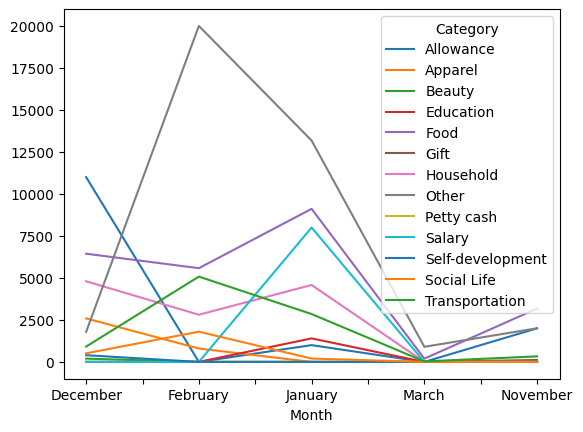

In [ ]:
df.pivot_table(index = 'Month', columns = 'Category', values = 'INR',aggfunc='sum', fill_value=0).plot()

<Axes: xlabel='Month'>

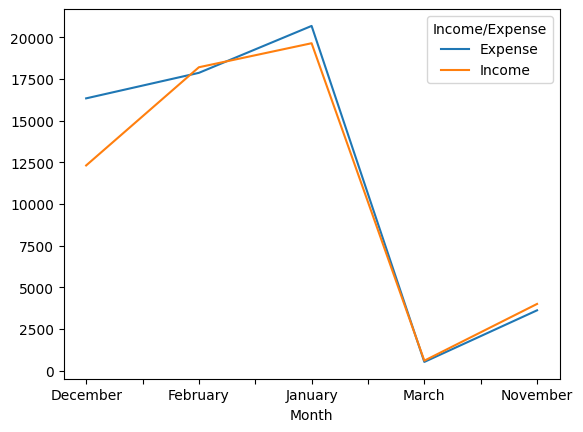

In [38]:
df.pivot_table(index = 'Month', columns = 'Income/Expense', values = 'INR',aggfunc='sum', fill_value=0).plot()

<Axes: xlabel='Month'>

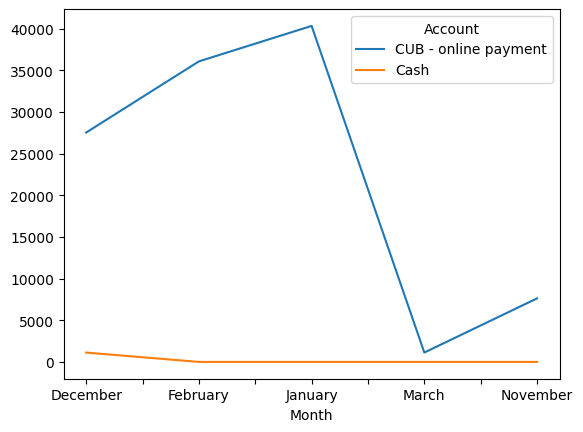

In [40]:
df.pivot_table(index = 'Month', columns = 'Account', values = 'INR',aggfunc='sum', fill_value=0).plot()